<a href="https://colab.research.google.com/github/wahyuherdiansyah32-maker/NLP_TUGASS/blob/main/NLP_TUGAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wordcloud -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive berhasil terhubung!")

Mounted at /content/drive
✅ Google Drive berhasil terhubung!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil di-import!")

✅ Semua library berhasil di-import!


In [9]:
path = '/content/drive/MyDrive/NLP_TUGAS/The_ Generative_AI.csv'

df = pd.read_csv(path, encoding='latin1')

# Rapikan nama kolom pertama (BOM issue)
df.columns.values[0] = 'App'

print("✅ Dataset berhasil dibaca!")
print(f"\nJumlah data: {len(df)} baris")
print(f"Kolom: {df.columns.tolist()}")
print(f"\nDistribusi Review_Theme:")
print(df['Review_Theme'].value_counts())
print("\nContoh data:")
print(df.head())

✅ Dataset berhasil dibaca!

Jumlah data: 50000 baris
Kolom: ['App', 'Review_Date', 'Star_Rating', 'Review_Text', 'Word_Count', 'Review_Length_Chars', 'Thumbs_Up_Count', 'App_Version', 'Sentiment_Polarity', 'Review_Theme']

Distribusi Review_Theme:
Review_Theme
General                  42931
Pricing/Subscription      2722
Accuracy/Logic Issues     2556
Bugs/Performance          1791
Name: count, dtype: int64

Contoh data:
       App          Review_Date  Star_Rating  \
0  ChatGPT  2026-03-31 12:12:53            5   
1  ChatGPT  2026-03-31 12:12:16            5   
2  ChatGPT  2026-03-31 12:11:43            1   
3  ChatGPT  2026-03-31 12:10:59            1   
4  ChatGPT  2026-03-31 12:06:35            5   

                                         Review_Text  Word_Count  \
0  ð ðð¦ ð¥ð¨ð¯ð¢ð§ð  ð¢ð...          18   
1  i love this app its very nice and super duper app          11   
2  THIS APP SUCKS THIS SHOULD NEVER EXIST ITS LIT...          17   
3  âIâm us

In [10]:
# ── Preprocessing Teks ──────────────────────────────────────────────────────
def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)   # hapus angka & simbol
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_preprocessed'] = df['Review_Text'].apply(preprocess_text)

# Hapus baris kosong
df = df.dropna(subset=['text_preprocessed', 'Review_Theme'])
df = df[df['text_preprocessed'].str.strip() != '']
df['Review_Theme'] = df['Review_Theme'].str.strip()

# Encode label ke angka
le = LabelEncoder()
df['label'] = le.fit_transform(df['Review_Theme'])

print(f"✅ Data setelah dibersihkan: {len(df)} baris")
print(f"\nKelas label:")
for i, cls in enumerate(le.classes_):
    count = (df['label'] == i).sum()
    print(f"  {i} = {cls}: {count} data")

✅ Data setelah dibersihkan: 49336 baris

Kelas label:
  0 = Accuracy/Logic Issues: 2556 data
  1 = Bugs/Performance: 1791 data
  2 = General: 42267 data
  3 = Pricing/Subscription: 2722 data


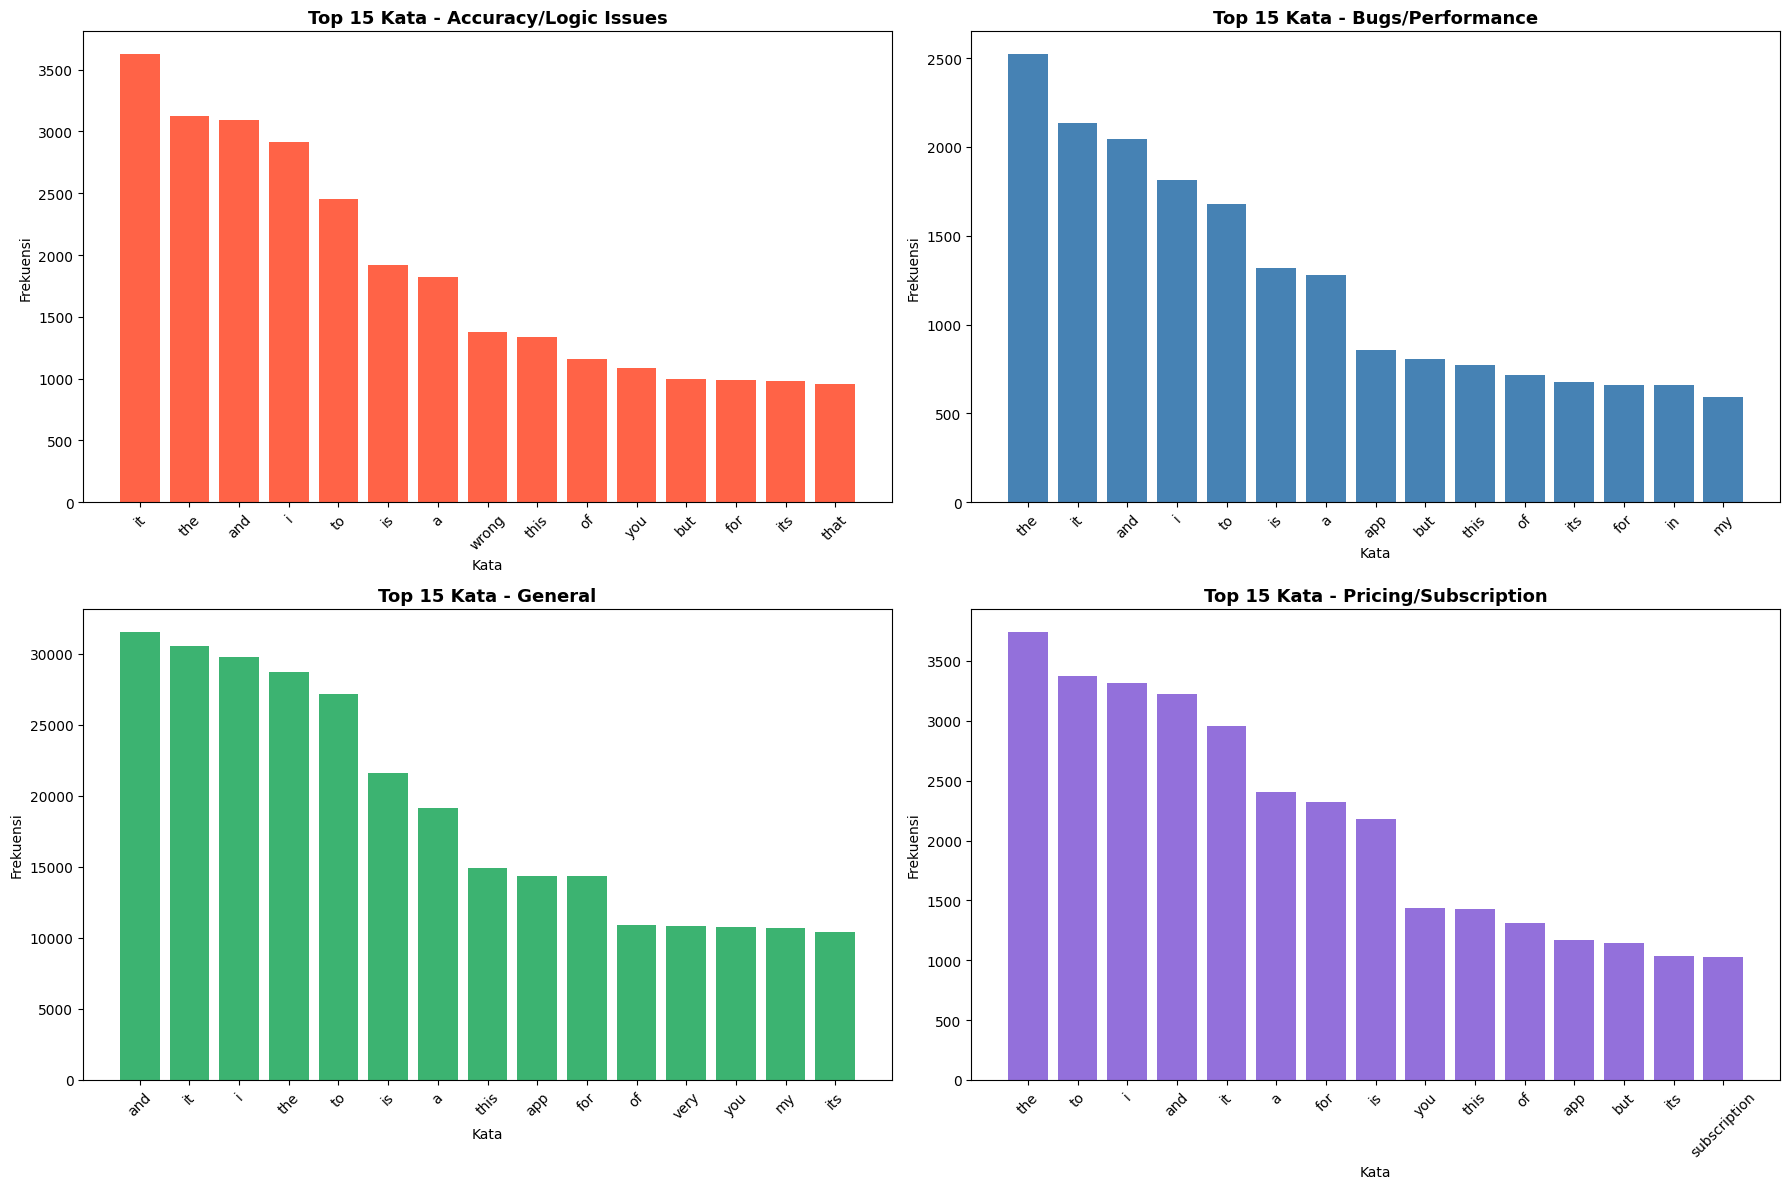

In [11]:
# ── Top 15 Kata per Kategori ─────────────────────────────────────────────────
categories = sorted(df['Review_Theme'].unique())

def hitung_frekuensi(teks, top_n=15):
    kata_list = teks.split()
    word_counts = {}
    for kata in kata_list:
        if kata in word_counts:
            word_counts[kata] += 1
        else:
            word_counts[kata] = 1
    sorted_counts = dict(sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:top_n])
    return sorted_counts

colors = ['tomato', 'steelblue', 'mediumseagreen', 'mediumpurple']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, cat in enumerate(categories):
    teks_cat = ' '.join(df[df['Review_Theme'] == cat]['text_preprocessed'].tolist())
    freq = hitung_frekuensi(teks_cat)
    axes[idx].bar(freq.keys(), freq.values(), color=colors[idx % len(colors)])
    axes[idx].set_title(f'Top 15 Kata - {cat}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Kata')
    axes[idx].set_ylabel('Frekuensi')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

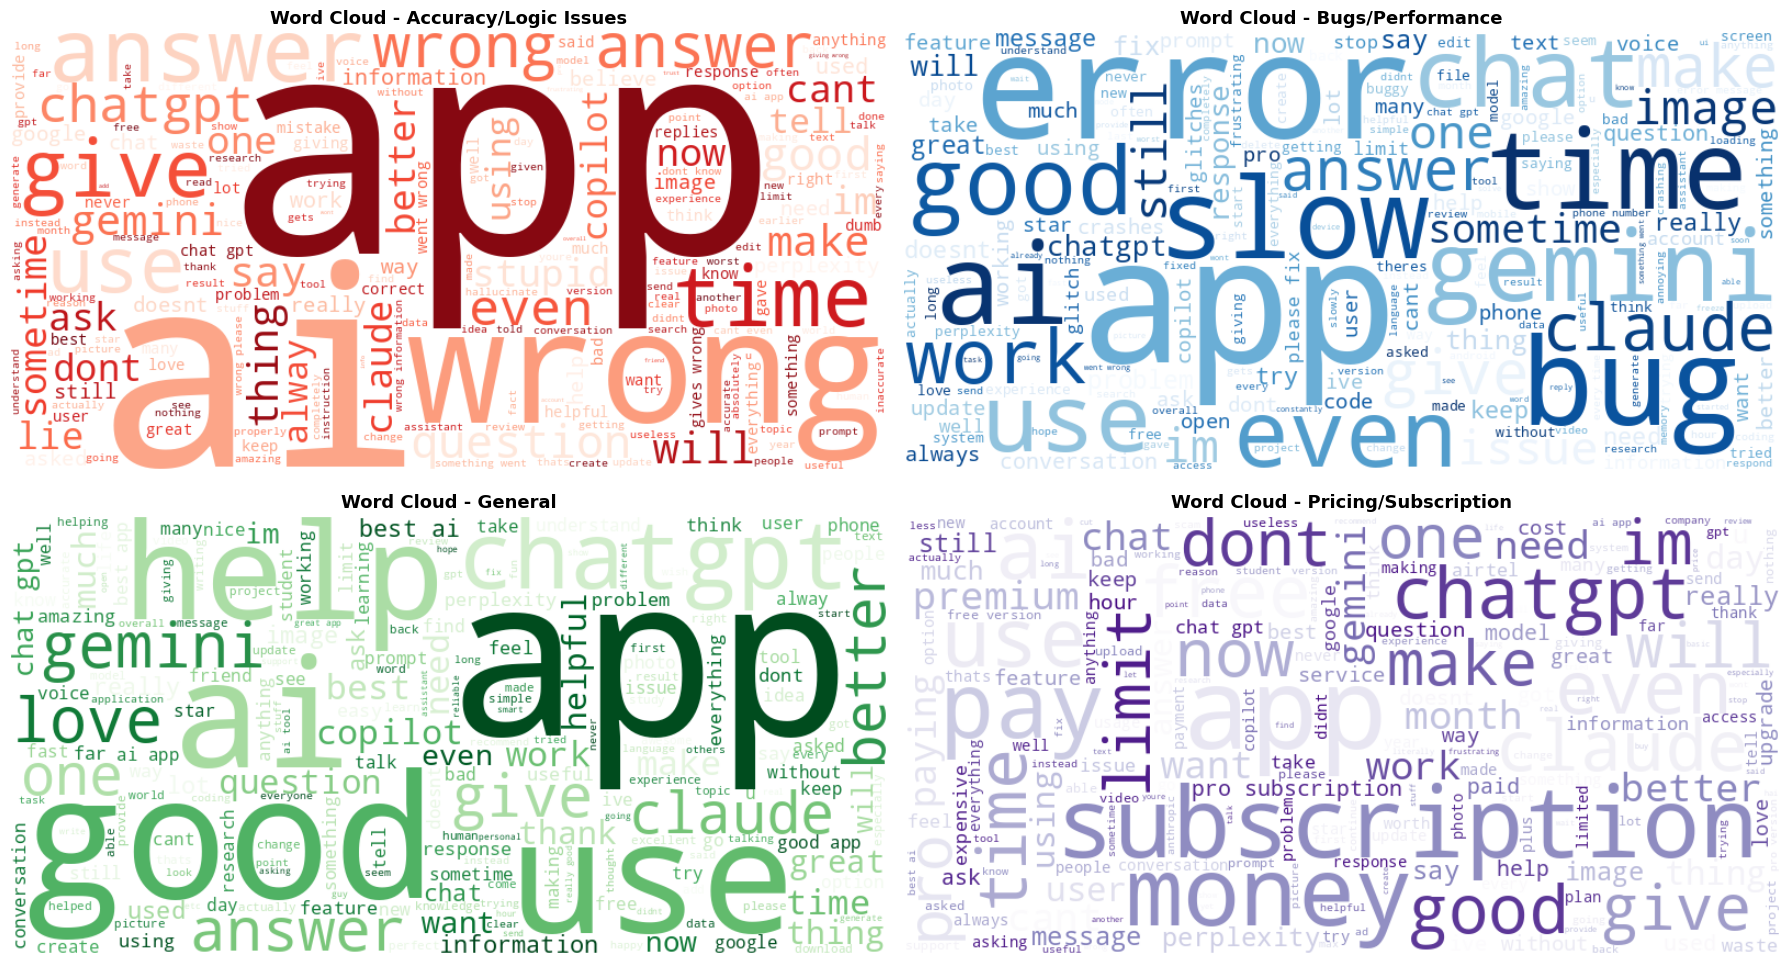

In [12]:
# ── Word Cloud per Kategori ───────────────────────────────────────────────────
cmaps = ['Reds', 'Blues', 'Greens', 'Purples']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for idx, cat in enumerate(categories):
    teks_cat = ' '.join(df[df['Review_Theme'] == cat]['text_preprocessed'].tolist())
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmaps[idx % len(cmaps)]).generate(teks_cat)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'Word Cloud - {cat}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# ── Contoh Matriks Bag of Words ───────────────────────────────────────────────
sample_texts = df['text_preprocessed'].head(5).tolist()
sample_vectorizer = CountVectorizer(max_features=15)
sample_matrix = sample_vectorizer.fit_transform(sample_texts)

bow_df = pd.DataFrame(
    sample_matrix.toarray(),
    columns=sample_vectorizer.get_feature_names_out()
)

print("Contoh Matriks Bag of Words (5 data pertama, 15 fitur):")
bow_df

Contoh Matriks Bag of Words (5 data pertama, 15 fitur):


,and,app,chatgpt,happy,im,in,is,it,its,like,or,the,this,very,voice
0,1,2,0,0,0,0,0,0,1,0,0,0,1,1,0
1,0,1,0,0,0,0,0,0,1,0,0,0,3,0,0
2,1,2,3,0,4,1,1,2,1,1,3,5,1,0,3
3,1,0,0,0,0,2,0,2,0,0,0,1,0,0,0
4,1,1,0,2,0,0,2,1,0,1,0,0,2,5,0


In [14]:
# ── Training Model Naive Bayes + BOW ─────────────────────────────────────────
vectorizer = CountVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['text_preprocessed'])
y = df['label']

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = MultinomialNB()
model.fit(X_train_bow, y_train)

y_pred = model.predict(X_test_bow)

akurasi = accuracy_score(y_test, y_pred)
print(f"✅ Model selesai dilatih!")
print(f"\nAkurasi Model: {akurasi * 100:.2f}%")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

✅ Model selesai dilatih!

Akurasi Model: 86.79%

Laporan Klasifikasi:
                       precision    recall  f1-score   support

Accuracy/Logic Issues       0.52      0.75      0.61       511
     Bugs/Performance       0.39      0.78      0.52       358
              General       0.98      0.88      0.93      8454
 Pricing/Subscription       0.57      0.85      0.68       545

             accuracy                           0.87      9868
            macro avg       0.61      0.81      0.68      9868
         weighted avg       0.91      0.87      0.88      9868



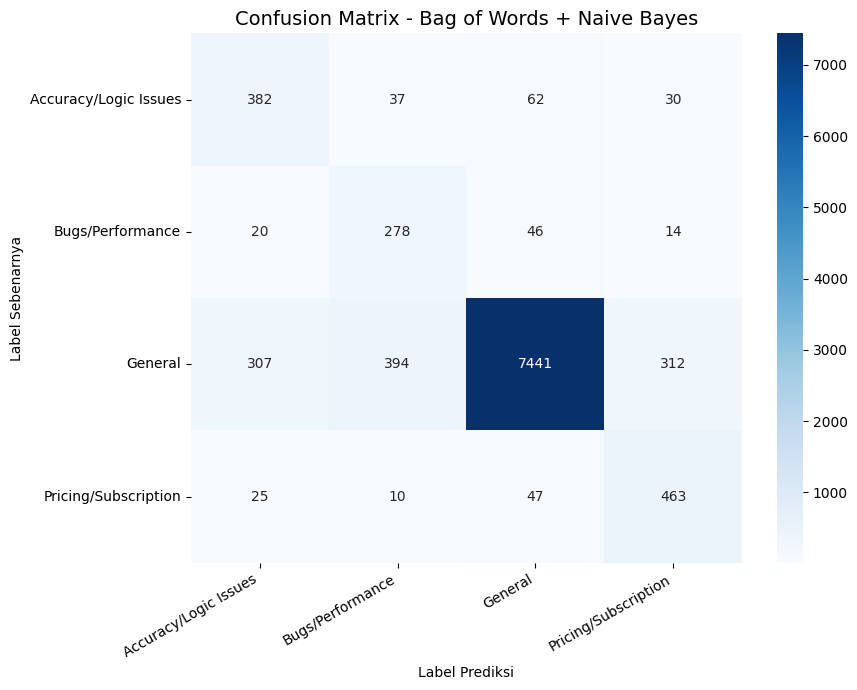


Detail Confusion Matrix:
  [Accuracy/Logic Issues] TP=382, FP=352, FN=129
  [Bugs/Performance] TP=278, FP=441, FN=80
  [General] TP=7441, FP=155, FN=1013
  [Pricing/Subscription] TP=463, FP=356, FN=82


In [15]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Bag of Words + Naive Bayes', fontsize=14)
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("\nDetail Confusion Matrix:")
for i, cls in enumerate(le.classes_):
    tp = cm[i][i]
    fn = cm[i].sum() - tp
    fp = cm[:, i].sum() - tp
    print(f"  [{cls}] TP={tp}, FP={fp}, FN={fn}")

In [16]:
# ── Fungsi Prediksi Review Baru ───────────────────────────────────────────────
def prediksi_review(teks):
    """
    Fungsi untuk memprediksi kategori review aplikasi Generative AI.
    """
    teks_bersih = re.sub(r'[^a-z\s]', '', teks.lower()).strip()
    teks_bow = vectorizer.transform([teks_bersih])

    hasil = model.predict(teks_bow)[0]
    proba = model.predict_proba(teks_bow)[0]

    label = le.inverse_transform([hasil])[0]
    print(f"Teks    : {teks}")
    print(f"Prediksi: 🏷️  {label}")
    print("Probabilitas per kategori:")
    for cls, p in zip(le.classes_, proba):
        bar = '█' * int(p * 30)
        print(f"  {cls:<30} {p*100:5.1f}% {bar}")
    print("-" * 55)

prediksi_review("this app crashes every time I open it, very buggy")
prediksi_review("I love this app it helps me write essays quickly")
prediksi_review("the subscription price is way too expensive for what you get")
prediksi_review("the answers are completely wrong and misleading")

Teks    : this app crashes every time I open it, very buggy
Prediksi: 🏷️  Bugs/Performance
Probabilitas per kategori:
  Accuracy/Logic Issues            0.0% 
  Bugs/Performance               100.0% █████████████████████████████
  General                          0.0% 
  Pricing/Subscription             0.0% 
-------------------------------------------------------
Teks    : I love this app it helps me write essays quickly
Prediksi: 🏷️  General
Probabilitas per kategori:
  Accuracy/Logic Issues            0.1% 
  Bugs/Performance                 0.1% 
  General                         99.8% █████████████████████████████
  Pricing/Subscription             0.0% 
-------------------------------------------------------
Teks    : the subscription price is way too expensive for what you get
Prediksi: 🏷️  Pricing/Subscription
Probabilitas per kategori:
  Accuracy/Logic Issues            0.0% 
  Bugs/Performance                 0.0% 
  General                          0.0% 
  Pricing/Subscripti